
---
## Section 6 - Evaluation & Comparative Results


In [ ]:
# 6.0 Walk-Forward Evaluation Loop

MODEL_FACTORIES = {
    'Logistic Regression': lambda: LogisticRegression(
        penalty='l2', C=1.0, solver='lbfgs', max_iter=1000, random_state=42
    ),
    'Random Forest': lambda: RandomForestClassifier(
        n_estimators=200, max_depth=6, min_samples_leaf=5,
        class_weight='balanced', random_state=42, n_jobs=-1
    ),
    'XGBoost': lambda: xgb.XGBClassifier(
        n_estimators=1000, learning_rate=0.001, max_depth=4,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='logloss', random_state=42
    ),
}

fold_records = []

for fold in FOLDS:
    tr_df = df[df['season'].isin(fold['train_seasons'])].copy()
    te_df = df[df['season'] == fold['test_season']].copy()

    X_tr_raw = tr_df[FEATURES].values
    y_tr     = tr_df[TARGET].values
    X_te_raw = te_df[FEATURES].values
    y_te     = te_df[TARGET].values

    fold_scaler = StandardScaler()
    X_tr_sc = fold_scaler.fit_transform(X_tr_raw)
    X_te_sc = fold_scaler.transform(X_te_raw)

    print(f"\n{'=' * 62}")
    print(f"  {fold['label']} - {fold['description']}")
    print(f"  Train: {len(tr_df)} matches  |  Test: {len(te_df)} matches")
    print(f"{'=' * 62}")
    print(f"  {'Model':<24} {'Accuracy':>10} {'F1 Score':>10} {'ROC-AUC':>10}")
    print(f"  {'-'*24} {'-'*10} {'-'*10} {'-'*10}")

    for model_name, factory in MODEL_FACTORIES.items():
        model = factory()
        if model_name == 'Logistic Regression':
            X_fit_tr, X_fit_te = X_tr_sc, X_te_sc
        else:
            X_fit_tr, X_fit_te = X_tr_raw, X_te_raw

        model.fit(X_fit_tr, y_tr)
        y_pred = model.predict(X_fit_te)
        y_prob = model.predict_proba(X_fit_te)[:, 1]

        acc = accuracy_score(y_te, y_pred)
        f1  = f1_score(y_te, y_pred, zero_division=0)
        auc = roc_auc_score(y_te, y_prob)

        print(f"  {model_name:<24} {acc:>10.4f} {f1:>10.4f} {auc:>10.4f}")

        fold_records.append({
            'Fold':      fold['label'],
            'Test Year': fold['test_season'],
            'Model':     model_name,
            'Accuracy':  acc,
            'F1 Score':  f1,
            'ROC-AUC':   auc,
        })

print(f"\nWalk-forward evaluation complete.  {len(fold_records)} records collected.")



  Fold 1 - Train: 2023  ->  Test: 2024
  Train: 330 matches  |  Test: 434 matches
  Model                      Accuracy   F1 Score    ROC-AUC
  ------------------------ ---------- ---------- ----------
  Logistic Regression          0.5138     0.5501     0.5705
  Random Forest                0.5415     0.5897     0.5709
  XGBoost                      0.5737     0.6105     0.5797

  Fold 2 - Train: 2023 + 2024  ->  Test: 2025
  Train: 764 matches  |  Test: 501 matches
  Model                      Accuracy   F1 Score    ROC-AUC
  ------------------------ ---------- ---------- ----------
  Logistic Regression          0.5988     0.6516     0.6596
  Random Forest                0.5968     0.6100     0.6263
  XGBoost                      0.6008     0.6678     0.6273

Walk-forward evaluation complete.  6 records collected.


In [ ]:
# 6.1 Forward-Testing Summary Table
wf_long = pd.DataFrame(fold_records)

wf_wide = wf_long.pivot_table(
    index='Model',
    columns='Fold',
    values=['Accuracy', 'F1 Score', 'ROC-AUC'],
)
wf_wide.columns = [f'{metric} ({fold})' for metric, fold in wf_wide.columns]
ordered_cols = sorted(wf_wide.columns, key=lambda c: (c.split('(')[-1], c))
wf_wide = wf_wide[ordered_cols]
wf_wide['ΔF1 (F2 − F1)'] = wf_wide['F1 Score (Fold 2)'] - wf_wide['F1 Score (Fold 1)']

print("=" * 90)
print("  WALK-FORWARD VALIDATION - CONSOLIDATED FORWARD-TESTING REPORT")
print("  Fold 1: Train 2023 → Test 2024  |  Fold 2: Train 2023+2024 → Test 2025")
print("=" * 90)
print(wf_wide.round(4).to_string())
print()

for fold_label in ['Fold 1', 'Fold 2']:
    best_f1_idx  = wf_wide[f'F1 Score ({fold_label})'].idxmax()
    best_auc_idx = wf_wide[f'ROC-AUC ({fold_label})'].idxmax()
    best_f1_val  = wf_wide.loc[best_f1_idx,  f'F1 Score ({fold_label})']
    best_auc_val = wf_wide.loc[best_auc_idx, f'ROC-AUC ({fold_label})']
    print(f"  {fold_label}   Best F1 : {best_f1_idx:<24} ({best_f1_val:.4f})")
    print(f"  {fold_label}   Best AUC: {best_auc_idx:<24} ({best_auc_val:.4f})")
    print()

most_stable = wf_wide['ΔF1 (F2 − F1)'].abs().idxmin()
print(f"   Most stable model (smallest |ΔF1|): {most_stable}"
      f"  (ΔF1 = {wf_wide.loc[most_stable, 'ΔF1 (F2 − F1)']:+.4f})")


  WALK-FORWARD VALIDATION - CONSOLIDATED FORWARD-TESTING REPORT
  Fold 1: Train 2023 → Test 2024  |  Fold 2: Train 2023+2024 → Test 2025
                     Accuracy (Fold 1)  F1 Score (Fold 1)  ROC-AUC (Fold 1)  Accuracy (Fold 2)  F1 Score (Fold 2)  ROC-AUC (Fold 2)  ΔF1 (F2 − F1)
Model                                                                                                                                             
Logistic Regression             0.5138             0.5501            0.5705             0.5988             0.6516            0.6596         0.1015
Random Forest                   0.5415             0.5897            0.5709             0.5968             0.6100            0.6263         0.0203
XGBoost                         0.5737             0.6105            0.5797             0.6008             0.6678            0.6273         0.0572

  Fold 1   Best F1 : XGBoost                  (0.6105)
  Fold 1   Best AUC: XGBoost                  (0.5797)

  Fold 2   Best 

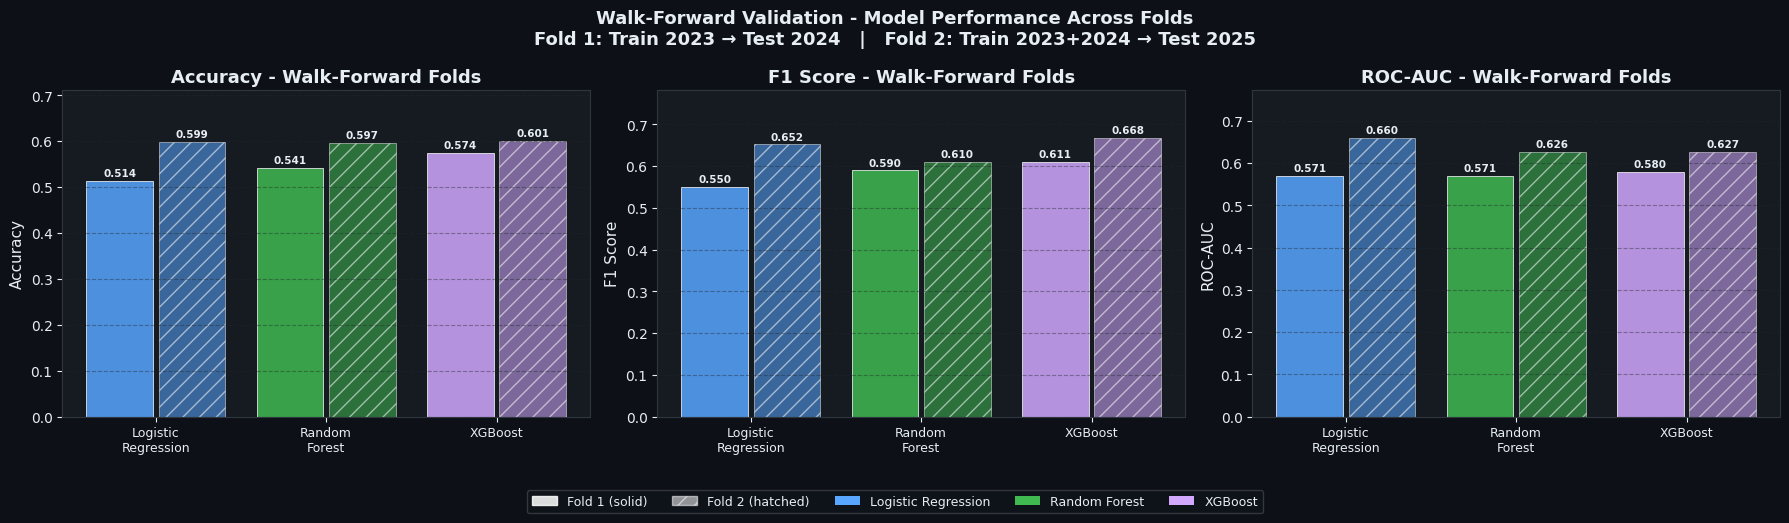

In [ ]:
# 6.1 Walk-Forward Visualisation - Grouped Bar Chart
METRIC_COLS  = ['Accuracy', 'F1 Score', 'ROC-AUC']
MODEL_NAMES  = list(MODEL_FACTORIES.keys())
FOLD_LABELS  = [f['label'] for f in FOLDS]
MODEL_COLORS = {
    'Logistic Regression': PALETTE[0],
    'Random Forest':       PALETTE[2],
    'XGBoost':             PALETTE[3],
}
FOLD_HATCHES = ['', '//']   # solid = Fold 1, hatched = Fold 2

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#0d1117')

n_models  = len(MODEL_NAMES)
group_gap = 0.15
bar_width = (1.0 - group_gap) / len(FOLD_LABELS)

for ax, metric in zip(axes, METRIC_COLS):
    for m_idx, model_name in enumerate(MODEL_NAMES):
        for f_idx, fold_label in enumerate(FOLD_LABELS):
            val   = wf_wide.loc[model_name, f'{metric} ({fold_label})']
            x_pos = m_idx + f_idx * bar_width - bar_width * (len(FOLD_LABELS) - 1) / 2
            ax.bar(
                x_pos, val, width=bar_width * 0.92,
                color=MODEL_COLORS[model_name],
                hatch=FOLD_HATCHES[f_idx],
                alpha=0.85 if f_idx == 0 else 0.55,
                edgecolor='white', linewidth=0.6,
                label=f'{model_name} - {fold_label}' if ax is axes[0] else None
            )
            ax.text(x_pos, val + 0.006, f'{val:.3f}',
                    ha='center', va='bottom', fontsize=7.5, fontweight='bold')

    ax.set_xticks(range(n_models))
    ax.set_xticklabels([n.replace(' ', '\n') for n in MODEL_NAMES], fontsize=9)
    ax.set_title(f'{metric} - Walk-Forward Folds', fontweight='bold')
    ax.set_ylabel(metric)
    ax.set_ylim(0, min(1.0, ax.get_ylim()[1] + 0.08))
    ax.set_facecolor('#161b22')
    ax.grid(axis='y', alpha=0.4)

from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor='white', edgecolor='white', alpha=0.85, label='Fold 1 (solid)'),
    Patch(facecolor='white', edgecolor='white', alpha=0.55, hatch='//',
          label='Fold 2 (hatched)'),
] + [Patch(facecolor=MODEL_COLORS[m], label=m) for m in MODEL_NAMES]
fig.legend(handles=legend_handles, loc='lower center', ncol=5,
           fontsize=9, framealpha=0.2, bbox_to_anchor=(0.5, -0.04))

plt.suptitle(
    'Walk-Forward Validation - Model Performance Across Folds\n'
    'Fold 1: Train 2023 → Test 2024   |   Fold 2: Train 2023+2024 → Test 2025',
    fontsize=13, fontweight='bold'
)
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()


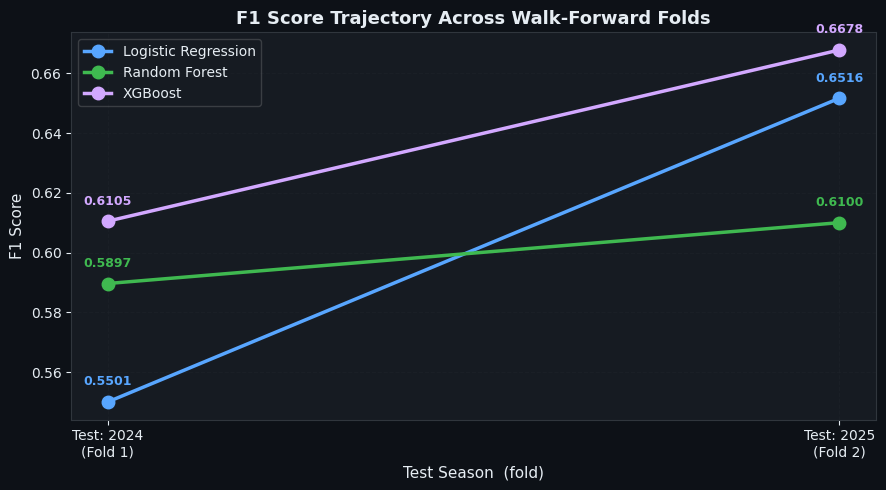


Fold-to-fold F1 change (positive = improved, negative = degraded):
  Model                     F1 Fold 1  F1 Fold 2        ΔF1  Verdict
  --------------------------------------------------------------------
  Logistic Regression          0.5501     0.6516    +0.1015   Stable / Improved
  Random Forest                0.5897     0.6100    +0.0203   Stable / Improved
  XGBoost                      0.6105     0.6678    +0.0572   Stable / Improved


In [ ]:
# 6.1 Walk-Forward Visualisation - F1 Trajectory & Stability Report
fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#161b22')

test_years = [f['test_season'] for f in FOLDS]

for model_name in MODEL_NAMES:
    f1_vals = [wf_wide.loc[model_name, f'F1 Score ({fl})'] for fl in FOLD_LABELS]
    ax.plot(test_years, f1_vals, 'o-', lw=2.5, ms=9,
            color=MODEL_COLORS[model_name], label=model_name)
    for yr, val in zip(test_years, f1_vals):
        ax.annotate(f'{val:.4f}', xy=(yr, val),
                    xytext=(0, 12), textcoords='offset points',
                    ha='center', fontsize=9, fontweight='bold',
                    color=MODEL_COLORS[model_name])

ax.set_xticks(test_years)
ax.set_xticklabels([f'Test: {yr}\n({fl})' for yr, fl in zip(test_years, FOLD_LABELS)])
ax.set_xlabel('Test Season  (fold)')
ax.set_ylabel('F1 Score')
ax.set_title('F1 Score Trajectory Across Walk-Forward Folds', fontweight='bold')
ax.legend(fontsize=10, framealpha=0.2)
ax.grid(alpha=0.4)
plt.tight_layout()
plt.show()

# -- Numeric stability report --------------------------------------------
print("\nFold-to-fold F1 change (positive = improved, negative = degraded):")
print(f"  {'Model':<24} {'F1 Fold 1':>10} {'F1 Fold 2':>10} {'ΔF1':>10}  Verdict")
print("  " + "-" * 68)
for model_name in MODEL_NAMES:
    f1_f1  = wf_wide.loc[model_name, 'F1 Score (Fold 1)']
    f1_f2  = wf_wide.loc[model_name, 'F1 Score (Fold 2)']
    delta  = f1_f2 - f1_f1
    verdict = " Stable / Improved" if delta >= -0.02 else "Degraded"
    print(f"  {model_name:<24} {f1_f1:>10.4f} {f1_f2:>10.4f} {delta:>+10.4f}  {verdict}")

In [ ]:
# 6.2 Evaluation Helper & Fold-2 Single-Split Metrics

def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    """Compute classification metrics for train and test sets."""
    y_pred_tr = model.predict(X_tr)
    y_pred_te = model.predict(X_te)
    y_prob_te = model.predict_proba(X_te)[:, 1]
    return {
        'Model':           name,
        'Train Acc':       accuracy_score(y_tr, y_pred_tr),
        'Test Accuracy':   accuracy_score(y_te, y_pred_te),
        'Precision':       precision_score(y_te, y_pred_te, zero_division=0),
        'Recall':          recall_score(y_te, y_pred_te, zero_division=0),
        'F1 Score':        f1_score(y_te, y_pred_te, zero_division=0),
        'ROC-AUC':         roc_auc_score(y_te, y_prob_te),
    }

results = [
    evaluate_model("Majority Baseline",   baseline,  X_train_sc, X_test_sc, y_train, y_test),
    evaluate_model("Logistic Regression", lr_model,  X_train_sc, X_test_sc, y_train, y_test),
    evaluate_model("Random Forest",       rf_model,  X_train,    X_test,    y_train, y_test),
    evaluate_model("XGBoost",             xgb_model, X_train,    X_test,    y_train, y_test),
]

results_df = pd.DataFrame(results).set_index('Model')
print("=" * 75)
print("  MODEL COMPARISON RESULTS (Evaluated on D3 - 2025 season, 501 matches)")
print("=" * 75)
print(results_df.round(4).to_string())
print()
best_f1  = results_df['F1 Score'].idxmax()
best_auc = results_df['ROC-AUC'].idxmax()
print(f"   Best F1 Score : {best_f1} ({results_df.loc[best_f1, 'F1 Score']:.4f})")
print(f"   Best ROC-AUC  : {best_auc} ({results_df.loc[best_auc, 'ROC-AUC']:.4f})")


  MODEL COMPARISON RESULTS (Evaluated on D3 - 2025 season, 501 matches)
                     Train Acc  Test Accuracy  Precision  Recall  F1 Score  ROC-AUC
Model                                                                              
Majority Baseline       0.5275         0.5210     0.5210  1.0000    0.6850   0.5000
Logistic Regression     0.5812         0.5988     0.5949  0.7203    0.6516   0.6596
Random Forest           0.7709         0.5948     0.6142  0.5977    0.6058   0.6242
XGBoost                 0.7277         0.6008     0.5894  0.7701    0.6678   0.6273

   Best F1 Score : Majority Baseline (0.6850)
   Best ROC-AUC  : Logistic Regression (0.6596)


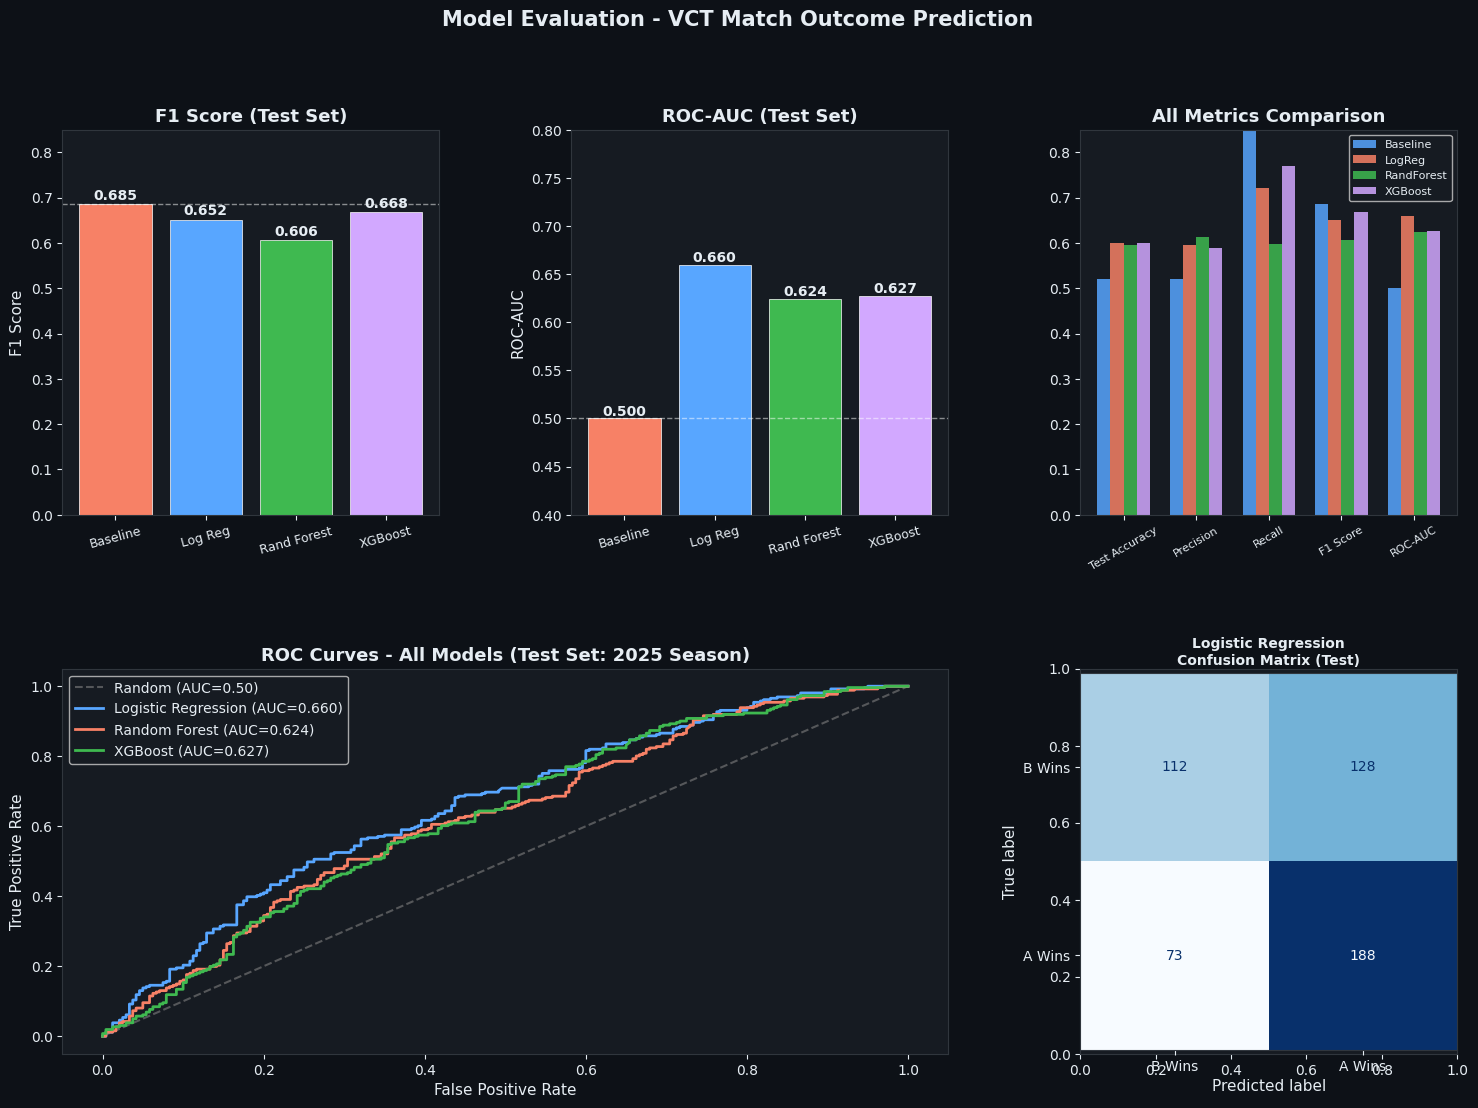

In [ ]:

# 6.2 Results Visualisation: Metric Comparison & ROC Curves
fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)
fig.patch.set_facecolor('#0d1117')

models_eval = [
    ("Majority Baseline",   baseline,  X_test_sc),
    ("Logistic Regression", lr_model,  X_test_sc),
    ("Random Forest",       rf_model,  X_test),
    ("XGBoost",             xgb_model, X_test),
]

# A) F1 Score bar chart
ax_f1 = fig.add_subplot(gs[0, 0])
f1_vals = results_df['F1 Score'].values
bars = ax_f1.bar(range(len(results_df)), f1_vals,
                 color=[PALETTE[1], PALETTE[0], PALETTE[2], PALETTE[3]],
                 edgecolor='white', linewidth=0.5)
ax_f1.set_xticks(range(len(results_df)))
ax_f1.set_xticklabels(['Baseline', 'Log Reg', 'Rand Forest', 'XGBoost'], rotation=15, fontsize=9)
ax_f1.set_title('F1 Score (Test Set)', fontweight='bold')
ax_f1.set_ylabel('F1 Score')
ax_f1.set_ylim(0, 0.85)
ax_f1.axhline(f1_vals[0], color='white', ls='--', alpha=0.5, lw=1, label='Baseline')
for bar, val in zip(bars, f1_vals):
    ax_f1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f'{val:.3f}',
               ha='center', fontsize=10, fontweight='bold')
ax_f1.set_facecolor('#161b22')

# B) ROC-AUC bar chart
ax_auc = fig.add_subplot(gs[0, 1])
auc_vals = results_df['ROC-AUC'].values
bars2 = ax_auc.bar(range(len(results_df)), auc_vals,
                   color=[PALETTE[1], PALETTE[0], PALETTE[2], PALETTE[3]],
                   edgecolor='white', linewidth=0.5)
ax_auc.set_xticks(range(len(results_df)))
ax_auc.set_xticklabels(['Baseline', 'Log Reg', 'Rand Forest', 'XGBoost'], rotation=15, fontsize=9)
ax_auc.axhline(0.5, color='white', ls='--', alpha=0.5, lw=1, label='Random (AUC=0.5)')
ax_auc.set_title('ROC-AUC (Test Set)', fontweight='bold')
ax_auc.set_ylabel('ROC-AUC')
ax_auc.set_ylim(0.4, 0.80)
for bar, val in zip(bars2, auc_vals):
    ax_auc.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003, f'{val:.3f}',
                ha='center', fontsize=10, fontweight='bold')
ax_auc.set_facecolor('#161b22')

# C) Full metric radar / grouped bar
ax_bar = fig.add_subplot(gs[0, 2])
metrics_to_plot = ['Test Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
x = np.arange(len(metrics_to_plot))
width = 0.18
model_names_short = ['Baseline', 'LogReg', 'RandForest', 'XGBoost']

for i, ((model_idx, model_row), color, lbl) in enumerate(zip(results_df.iterrows(), PALETTE, model_names_short)):
    vals = [model_row[m] for m in metrics_to_plot]
    ax_bar.bar(x + i*width, vals, width, label=lbl, color=color, alpha=0.85)

ax_bar.set_xticks(x + 1.5*width)
ax_bar.set_xticklabels(metrics_to_plot, rotation=30, fontsize=8)
ax_bar.set_title('All Metrics Comparison', fontweight='bold')
ax_bar.set_ylim(0, 0.85)
ax_bar.legend(fontsize=8, loc='upper right')
ax_bar.set_facecolor('#161b22')

# D) ROC Curves
ax_roc = fig.add_subplot(gs[1, :2])
ax_roc.plot([0,1],[0,1], '--', color='gray', alpha=0.6, label='Random (AUC=0.50)', lw=1.5)
for (name, model, X_eval), color in zip(models_eval[1:], PALETTE):  # skip baseline
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_eval)[:,1])
    auc_val = roc_auc_score(y_test, model.predict_proba(X_eval)[:,1])
    ax_roc.plot(fpr, tpr, lw=2, color=color, label=f'{name} (AUC={auc_val:.3f})')
ax_roc.set_xlabel('False Positive Rate')
ax_roc.set_ylabel('True Positive Rate')
ax_roc.set_title('ROC Curves - All Models (Test Set: 2025 Season)', fontweight='bold')
ax_roc.legend(fontsize=10)
ax_roc.set_facecolor('#161b22')

# E) Confusion Matrices
for idx, (name, model, X_eval, color) in enumerate(
        [("LogReg", lr_model, X_test_sc, PALETTE[0]),
         ("XGBoost", xgb_model, X_test, PALETTE[3])]):
    ax_cm = fig.add_subplot(gs[1, 2] if idx == 1 else gs[1, 2])
    break

ax_cm1 = fig.add_subplot(gs[1, 2])
cm1 = confusion_matrix(y_test, lr_model.predict(X_test_sc))
disp1 = ConfusionMatrixDisplay(cm1, display_labels=['B Wins', 'A Wins'])
disp1.plot(ax=ax_cm1, colorbar=False, cmap='Blues')
ax_cm1.set_title('Logistic Regression\nConfusion Matrix (Test)', fontweight='bold', fontsize=10)
ax_cm1.set_facecolor('#161b22')

plt.suptitle('Model Evaluation - VCT Match Outcome Prediction', fontsize=15, fontweight='bold')
plt.show()


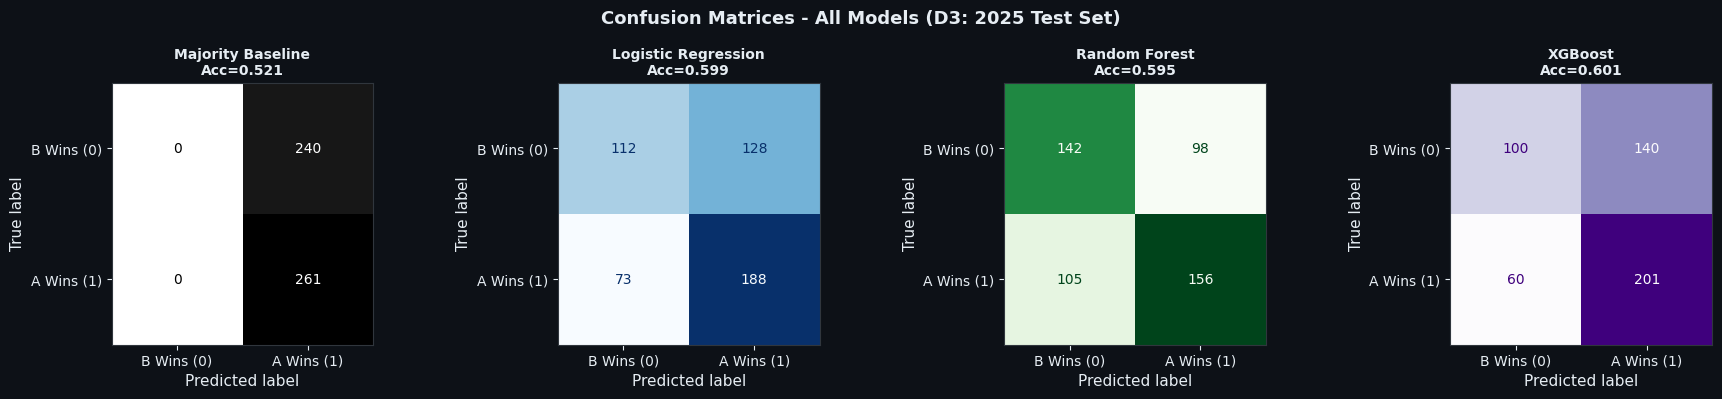

In [ ]:

# 6.3 Confusion Matrices - All Models
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.patch.set_facecolor('#0d1117')

for ax, (name, model, X_eval), cmap in zip(
        axes,
        models_eval,
        ['Greys', 'Blues', 'Greens', 'Purples']):
    cm = confusion_matrix(y_test, model.predict(X_eval))
    disp = ConfusionMatrixDisplay(cm, display_labels=['B Wins (0)', 'A Wins (1)'])
    disp.plot(ax=ax, colorbar=False, cmap=cmap)
    acc = accuracy_score(y_test, model.predict(X_eval))
    ax.set_title(f'{name}\nAcc={acc:.3f}', fontweight='bold', fontsize=10)
    ax.set_facecolor('#161b22')

plt.suptitle('Confusion Matrices - All Models (D3: 2025 Test Set)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


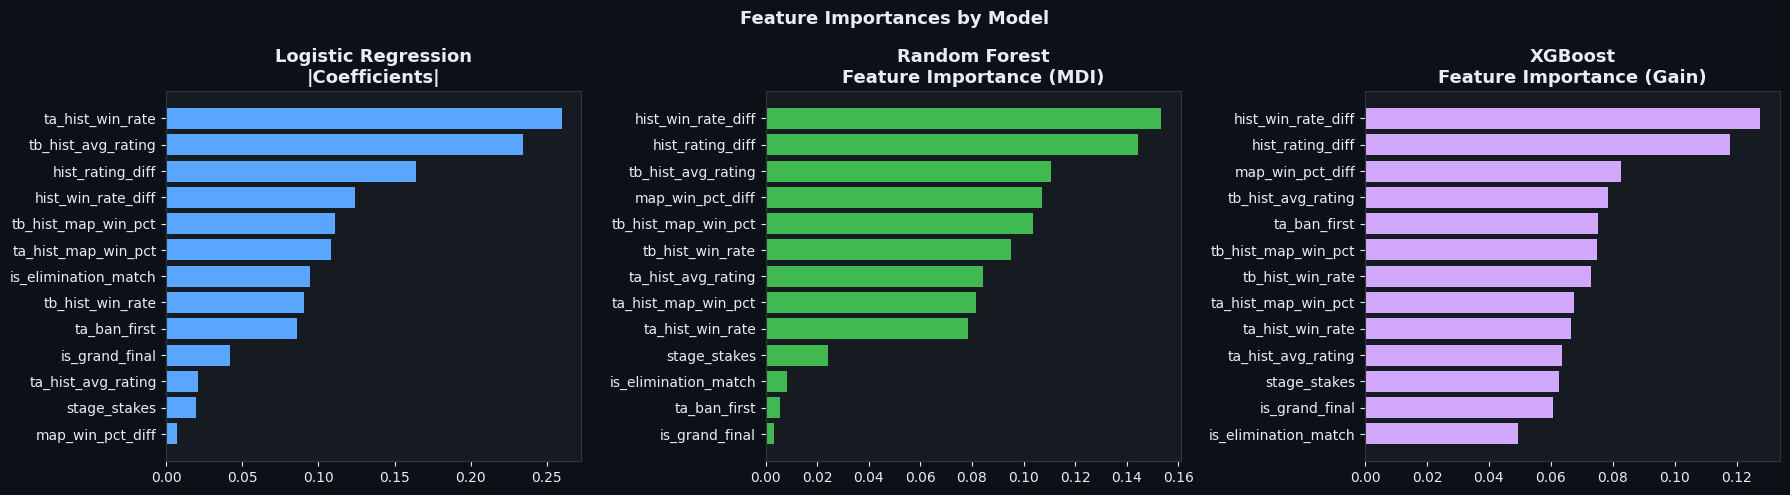


Key finding: Feature importance varies significantly across models.
   While XGBoost and Random Forest prioritize engineered differentials (win rate and rating diff),
   Logistic Regression relies more on absolute baseline stats like 'ta_hist_win_rate'.
   The low importance of 'map_win_pct_diff' in the linear model suggests high redundancy,
   highlighting the need for ensemble models to capture complex VCT performance dynamics.


In [ ]:
# 6.4 Feature Importances
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#0d1117')

# Logistic Regression: absolute coefficient magnitudes
lr_coef = np.abs(lr_model.coef_[0])
lr_order = np.argsort(lr_coef)
axes[0].barh([FEATURES[i] for i in lr_order], lr_coef[lr_order], color=PALETTE[0])
axes[0].set_title('Logistic Regression\n|Coefficients|', fontweight='bold')
axes[0].set_facecolor('#161b22')

# Random Forest: mean decrease in impurity
rf_imp = rf_model.feature_importances_
rf_order = np.argsort(rf_imp)
axes[1].barh([FEATURES[i] for i in rf_order], rf_imp[rf_order], color=PALETTE[2])
axes[1].set_title('Random Forest\nFeature Importance (MDI)', fontweight='bold')
axes[1].set_facecolor('#161b22')

# XGBoost: weight-based importance
xgb_imp = xgb_model.feature_importances_
xgb_order = np.argsort(xgb_imp)
axes[2].barh([FEATURES[i] for i in xgb_order], xgb_imp[xgb_order], color=PALETTE[3])
axes[2].set_title('XGBoost\nFeature Importance (Gain)', fontweight='bold')
axes[2].set_facecolor('#161b22')

plt.suptitle('Feature Importances by Model', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nKey finding: Feature importance varies significantly across models.")
print("   While XGBoost and Random Forest prioritize engineered differentials (win rate and rating diff),")
print("   Logistic Regression relies more on absolute baseline stats like 'ta_hist_win_rate'.")
print("   The low importance of 'map_win_pct_diff' in the linear model suggests high redundancy,")
print("   highlighting the need for ensemble models to capture complex VCT performance dynamics.")